In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

Загружается датасет MNIST, выполняется разбиение на обучающую, валидационную и тестовую выборки. Также создаются DataLoader’ы для батчевой обработки данных при обучении модели.

In [2]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [3]:
transform = transforms.ToTensor()

full_train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_size = 50000
val_size = 10000
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Отображаются примеры изображений из датасета MNIST вместе с их метками классов.

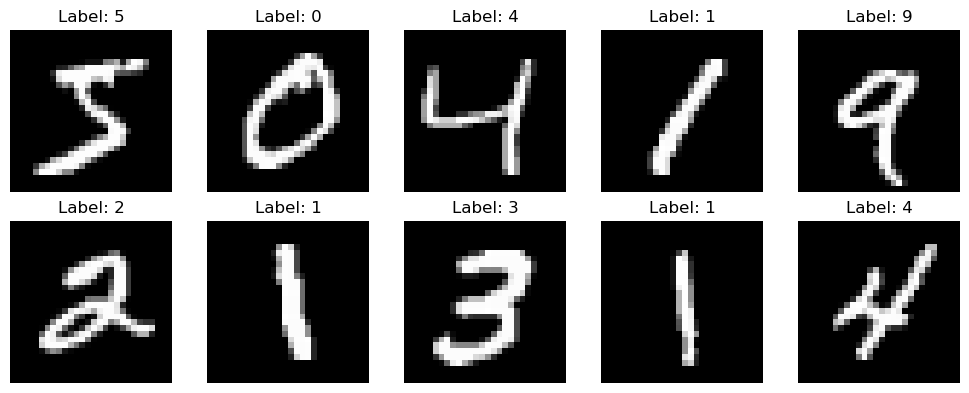

In [4]:
classes = [str(i) for i in range(10)]

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i in range(10):
    image, label = full_train_dataset[i]
    ax = axes[i // 5, i % 5]
    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")
plt.tight_layout()
plt.show()

Определяются функции для обучения модели и вычисления метрик качества (loss, accuracy, precision, recall, F1-score). Эти функции используются для всех моделей, чтобы обеспечить единый подход к оценке.

In [5]:
def evaluate_model(model, loader, criterion):
    model.eval()
    total_loss = 0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            loss = criterion(outputs, y)
            total_loss += loss.item() * x.size(0)

            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(y.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_targets, all_preds)
    precision = precision_score(all_targets, all_preds, average="macro", zero_division=0)
    recall = recall_score(all_targets, all_preds, average="macro", zero_division=0)
    f1 = f1_score(all_targets, all_preds, average="macro", zero_division=0)

    return avg_loss, acc, precision, recall, f1

In [6]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_acc": [],
        "val_precision": [],
        "val_recall": [],
        "val_f1": []
    }

    for epoch in range(epochs):
        model.train()
        running_loss = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * x.size(0)

        train_loss = running_loss / len(train_loader.dataset)
        val_loss, val_acc, val_precision, val_recall, val_f1 = evaluate_model(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_precision"].append(val_precision)
        history["val_recall"].append(val_recall)
        history["val_f1"].append(val_f1)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
            f"val_acc={val_acc:.4f} | val_f1={val_f1:.4f}"
        )

    return history

In [7]:
def plot_history(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} - Loss")
    plt.legend()
    plt.grid()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["val_acc"], label="Accuracy")
    plt.plot(epochs, history["val_precision"], label="Precision")
    plt.plot(epochs, history["val_recall"], label="Recall")
    plt.plot(epochs, history["val_f1"], label="F1-score")
    plt.xlabel("Epoch")
    plt.ylabel("Metric")
    plt.title(f"{title} - Metrics")
    plt.legend()
    plt.grid()
    plt.show()

Реализуется полносвязная нейронная сеть с функцией активации ReLU. В модель добавляется регуляризация (Dropout и weight decay) для уменьшения переобучения. Проводится обучение и строятся графики функции потерь и метрик.

In [8]:
class MLPReLUWithReg(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)

In [9]:
model_reg = MLPReLUWithReg().to(device)
criterion = nn.CrossEntropyLoss()
optimizer_reg = optim.Adam(model_reg.parameters(), lr=0.001, weight_decay=1e-4)

history_reg = train_model(model_reg, train_loader, val_loader, criterion, optimizer_reg, epochs=10)

Epoch 1/10 | train_loss=0.4595 | val_loss=0.2060 | val_acc=0.9379 | val_f1=0.9372
Epoch 2/10 | train_loss=0.1909 | val_loss=0.1420 | val_acc=0.9587 | val_f1=0.9582
Epoch 3/10 | train_loss=0.1435 | val_loss=0.1135 | val_acc=0.9667 | val_f1=0.9663
Epoch 4/10 | train_loss=0.1146 | val_loss=0.0998 | val_acc=0.9698 | val_f1=0.9695
Epoch 5/10 | train_loss=0.0989 | val_loss=0.0994 | val_acc=0.9687 | val_f1=0.9684
Epoch 6/10 | train_loss=0.0891 | val_loss=0.0867 | val_acc=0.9729 | val_f1=0.9726
Epoch 7/10 | train_loss=0.0785 | val_loss=0.0838 | val_acc=0.9732 | val_f1=0.9730
Epoch 8/10 | train_loss=0.0716 | val_loss=0.0876 | val_acc=0.9718 | val_f1=0.9715
Epoch 9/10 | train_loss=0.0658 | val_loss=0.0796 | val_acc=0.9748 | val_f1=0.9746
Epoch 10/10 | train_loss=0.0623 | val_loss=0.0762 | val_acc=0.9772 | val_f1=0.9770


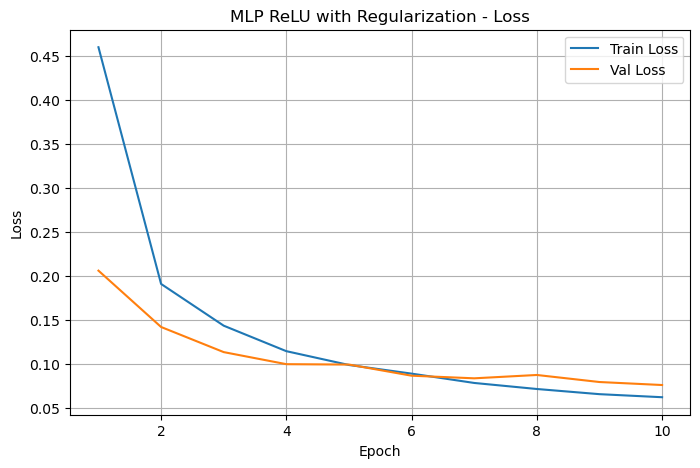

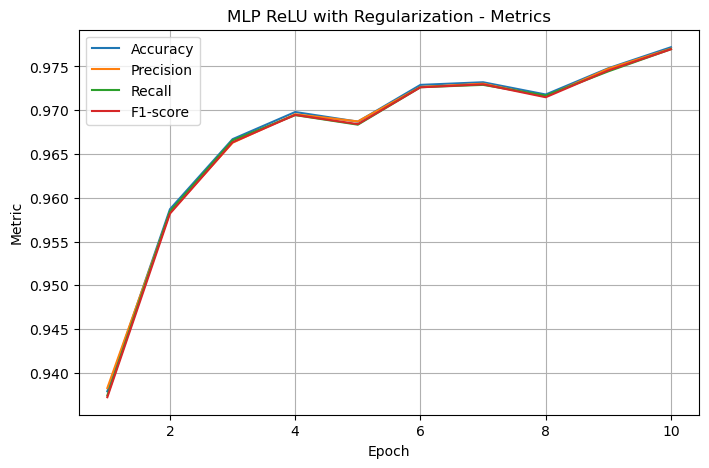

In [10]:
plot_history(history_reg, "MLP ReLU with Regularization")

In [32]:
test_metrics_reg = evaluate_model(model_reg, test_loader, criterion)
test_metrics_reg

(0.06531774037578143,
 0.9793,
 0.9791797784441499,
 0.9790873186664524,
 0.9791069623061514)

Из модели убираются методы регуляризации. Проводится повторное обучение и сравнение с предыдущей моделью для анализа влияния регуляризации на качество и переобучение.

In [11]:
class MLPReLUWithoutReg(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)

In [12]:
model_no_reg = MLPReLUWithoutReg().to(device)
criterion = nn.CrossEntropyLoss()
optimizer_no_reg = optim.Adam(model_no_reg.parameters(), lr=0.001)

history_no_reg = train_model(model_no_reg, train_loader, val_loader, criterion, optimizer_no_reg, epochs=10)

Epoch 1/10 | train_loss=0.3814 | val_loss=0.2038 | val_acc=0.9396 | val_f1=0.9391
Epoch 2/10 | train_loss=0.1463 | val_loss=0.1360 | val_acc=0.9580 | val_f1=0.9575
Epoch 3/10 | train_loss=0.0974 | val_loss=0.1195 | val_acc=0.9649 | val_f1=0.9645
Epoch 4/10 | train_loss=0.0694 | val_loss=0.1129 | val_acc=0.9639 | val_f1=0.9635
Epoch 5/10 | train_loss=0.0555 | val_loss=0.0980 | val_acc=0.9703 | val_f1=0.9701
Epoch 6/10 | train_loss=0.0418 | val_loss=0.0960 | val_acc=0.9723 | val_f1=0.9721
Epoch 7/10 | train_loss=0.0324 | val_loss=0.0986 | val_acc=0.9705 | val_f1=0.9702
Epoch 8/10 | train_loss=0.0240 | val_loss=0.0910 | val_acc=0.9749 | val_f1=0.9746
Epoch 9/10 | train_loss=0.0201 | val_loss=0.1015 | val_acc=0.9726 | val_f1=0.9723
Epoch 10/10 | train_loss=0.0154 | val_loss=0.0933 | val_acc=0.9756 | val_f1=0.9753


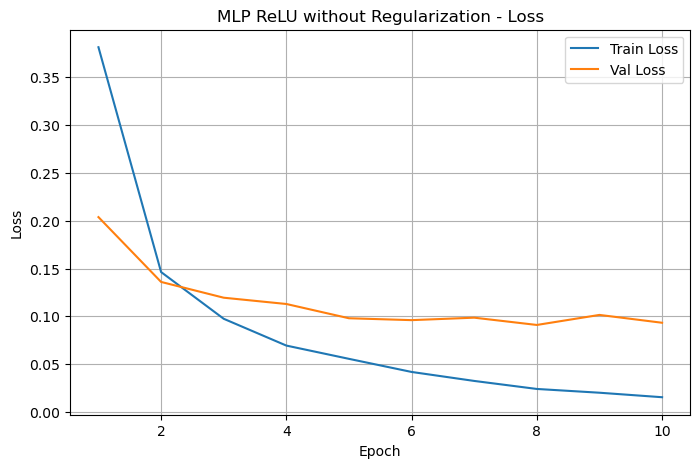

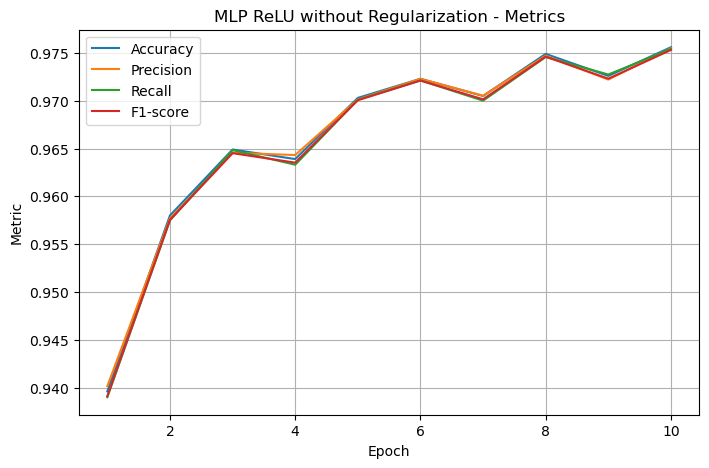

In [13]:
plot_history(history_no_reg, "MLP ReLU without Regularization")

In [14]:
test_metrics_no_reg = evaluate_model(model_no_reg, test_loader, criterion)
test_metrics_no_reg

(0.08106474572718143,
 0.9768,
 0.9767039745113216,
 0.9767333959474647,
 0.9766256964354948)

Строятся графики, позволяющие сравнить поведение функции потерь и метрик качества для моделей с регуляризацией и без неё.

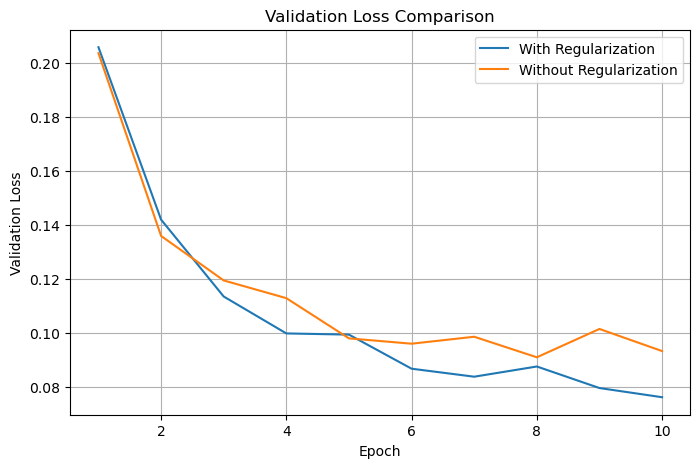

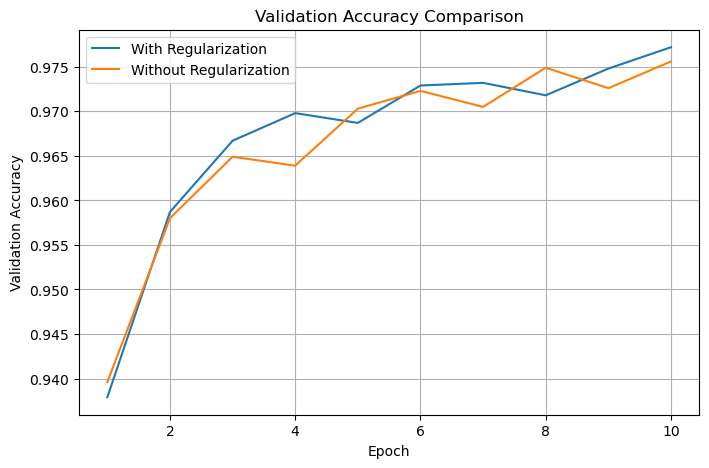

In [15]:
epochs = range(1, len(history_reg["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history_reg["val_loss"], label="With Regularization")
plt.plot(epochs, history_no_reg["val_loss"], label="Without Regularization")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, history_reg["val_acc"], label="With Regularization")
plt.plot(epochs, history_no_reg["val_acc"], label="Without Regularization")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")
plt.legend()
plt.grid()
plt.show()

Функция активации ReLU заменяется на Sigmoid. Проводится обучение и анализируется влияние функции активации на скорость сходимости и итоговое качество модели.

In [16]:
class MLPSigmoid(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(28 * 28, 256),
            nn.Sigmoid(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.Sigmoid(),
            nn.Dropout(0.3),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)

In [17]:
model_sigmoid = MLPSigmoid().to(device)
criterion = nn.CrossEntropyLoss()
optimizer_sigmoid = optim.Adam(model_sigmoid.parameters(), lr=0.001, weight_decay=1e-4)

history_sigmoid = train_model(model_sigmoid, train_loader, val_loader, criterion, optimizer_sigmoid, epochs=10)

Epoch 1/10 | train_loss=0.9256 | val_loss=0.3596 | val_acc=0.8978 | val_f1=0.8962
Epoch 2/10 | train_loss=0.3445 | val_loss=0.2664 | val_acc=0.9195 | val_f1=0.9182
Epoch 3/10 | train_loss=0.2767 | val_loss=0.2247 | val_acc=0.9335 | val_f1=0.9325
Epoch 4/10 | train_loss=0.2397 | val_loss=0.1974 | val_acc=0.9402 | val_f1=0.9395
Epoch 5/10 | train_loss=0.2129 | val_loss=0.1772 | val_acc=0.9466 | val_f1=0.9460
Epoch 6/10 | train_loss=0.1953 | val_loss=0.1592 | val_acc=0.9518 | val_f1=0.9512
Epoch 7/10 | train_loss=0.1809 | val_loss=0.1479 | val_acc=0.9548 | val_f1=0.9543
Epoch 8/10 | train_loss=0.1672 | val_loss=0.1382 | val_acc=0.9572 | val_f1=0.9568
Epoch 9/10 | train_loss=0.1564 | val_loss=0.1340 | val_acc=0.9592 | val_f1=0.9588
Epoch 10/10 | train_loss=0.1507 | val_loss=0.1264 | val_acc=0.9598 | val_f1=0.9593


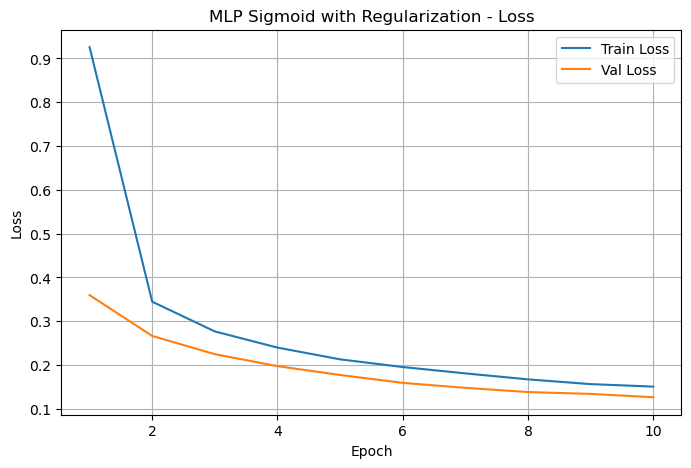

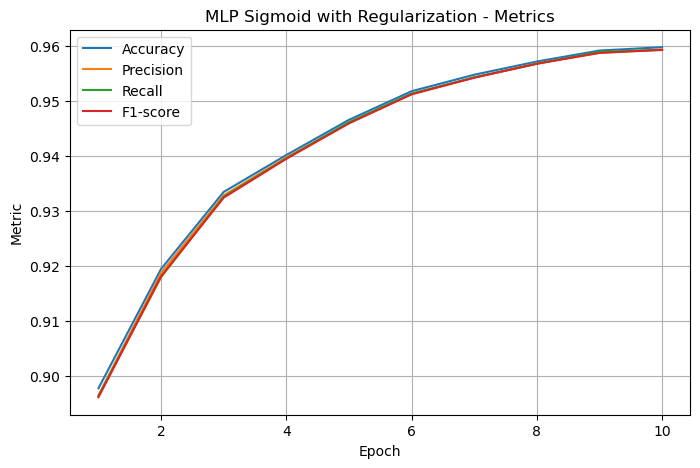

In [18]:
plot_history(history_sigmoid, "MLP Sigmoid with Regularization")

In [19]:
test_metrics_sigmoid = evaluate_model(model_sigmoid, test_loader, criterion)
test_metrics_sigmoid

(0.10963260879218578,
 0.9675,
 0.9672056208815428,
 0.9671405282208732,
 0.9671428100055544)

Сравниваются метрики и функция потерь для моделей с разными функциями активации, чтобы оценить влияние выбора активации на обучение.

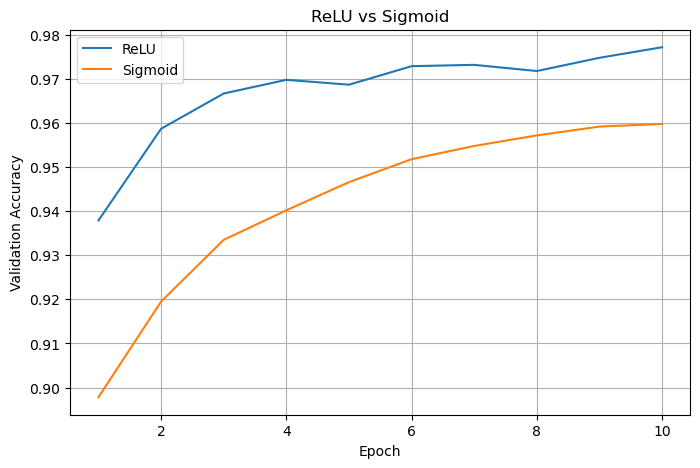

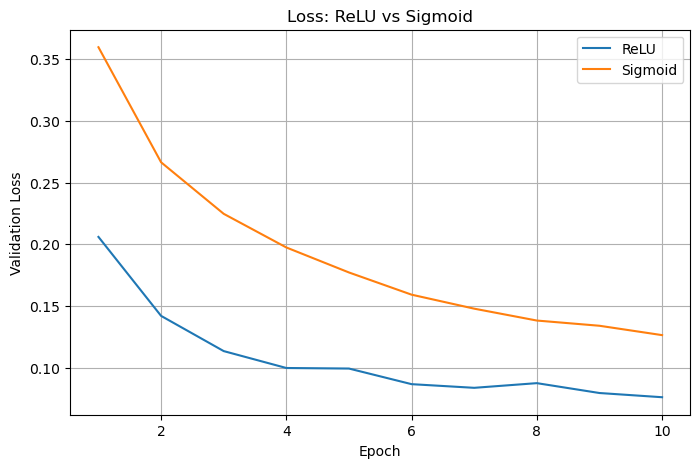

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, history_reg["val_acc"], label="ReLU")
plt.plot(epochs, history_sigmoid["val_acc"], label="Sigmoid")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("ReLU vs Sigmoid")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, history_reg["val_loss"], label="ReLU")
plt.plot(epochs, history_sigmoid["val_loss"], label="Sigmoid")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Loss: ReLU vs Sigmoid")
plt.legend()
plt.grid()
plt.show()

Реализуется простая сверточная нейронная сеть, учитывающая пространственную структуру изображений. Проводится обучение и оценивается качество модел

In [21]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x

In [22]:
cnn_model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer_cnn = optim.Adam(cnn_model.parameters(), lr=0.001)

history_cnn = train_model(cnn_model, train_loader, val_loader, criterion, optimizer_cnn, epochs=10)

Epoch 1/10 | train_loss=0.3283 | val_loss=0.1150 | val_acc=0.9662 | val_f1=0.9661
Epoch 2/10 | train_loss=0.0875 | val_loss=0.0810 | val_acc=0.9767 | val_f1=0.9766
Epoch 3/10 | train_loss=0.0588 | val_loss=0.0652 | val_acc=0.9800 | val_f1=0.9797
Epoch 4/10 | train_loss=0.0457 | val_loss=0.0617 | val_acc=0.9805 | val_f1=0.9803
Epoch 5/10 | train_loss=0.0366 | val_loss=0.0495 | val_acc=0.9854 | val_f1=0.9853
Epoch 6/10 | train_loss=0.0309 | val_loss=0.0461 | val_acc=0.9855 | val_f1=0.9853
Epoch 7/10 | train_loss=0.0255 | val_loss=0.0506 | val_acc=0.9859 | val_f1=0.9857
Epoch 8/10 | train_loss=0.0230 | val_loss=0.0464 | val_acc=0.9867 | val_f1=0.9866
Epoch 9/10 | train_loss=0.0191 | val_loss=0.0490 | val_acc=0.9854 | val_f1=0.9853
Epoch 10/10 | train_loss=0.0162 | val_loss=0.0475 | val_acc=0.9875 | val_f1=0.9874


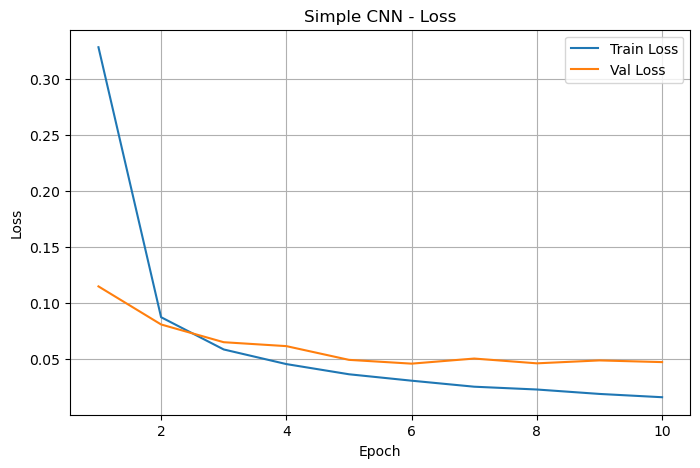

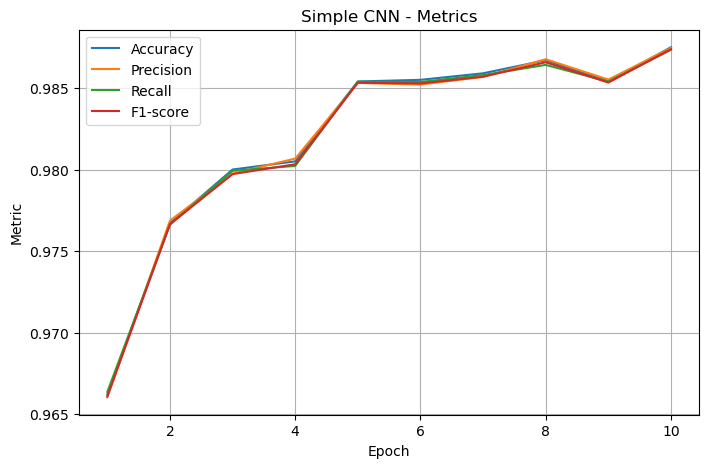

In [23]:
plot_history(history_cnn, "Simple CNN")

In [24]:
test_metrics_cnn = evaluate_model(cnn_model, test_loader, criterion)
test_metrics_cnn

(0.03627269684965722,
 0.99,
 0.9900510906154738,
 0.989962303183046,
 0.9899897222717959)

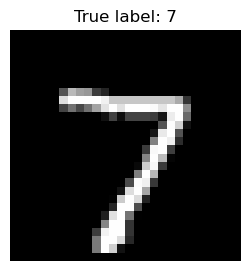

In [25]:
sample_image, sample_label = test_dataset[0]
plt.figure(figsize=(3, 3))
plt.imshow(sample_image.squeeze(), cmap="gray")
plt.title(f"True label: {sample_label}")
plt.axis("off")
plt.show()

In [26]:
activations = {}

def get_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach().cpu()
    return hook

hook1 = cnn_model.conv1.register_forward_hook(get_activation("conv1"))
hook2 = cnn_model.conv2.register_forward_hook(get_activation("conv2"))

In [27]:
cnn_model.eval()
with torch.no_grad():
    input_tensor = sample_image.unsqueeze(0).to(device)
    output = cnn_model(input_tensor)
    predicted_label = output.argmax(dim=1).item()

predicted_label

7

С помощью forward hooks извлекаются и визуализируются карты активаций первых сверточных слоев. Это позволяет увидеть, какие признаки извлекает сеть.

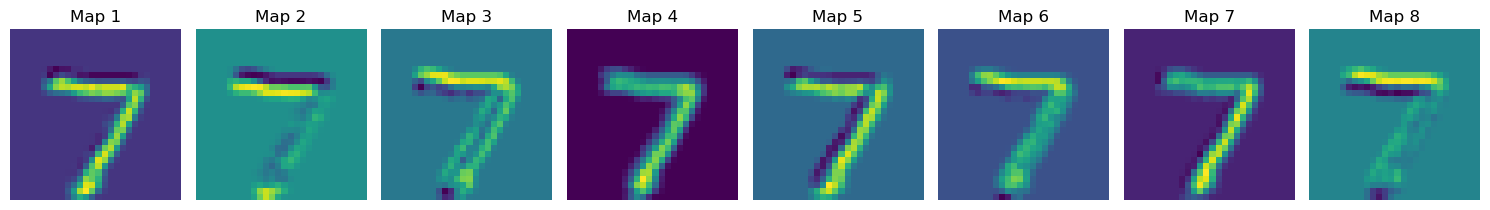

In [28]:
conv1_maps = activations["conv1"][0]
num_maps = min(8, conv1_maps.shape[0])

fig, axes = plt.subplots(1, num_maps, figsize=(15, 3))
for i in range(num_maps):
    axes[i].imshow(conv1_maps[i], cmap="viridis")
    axes[i].axis("off")
    axes[i].set_title(f"Map {i+1}")
plt.tight_layout()
plt.show()

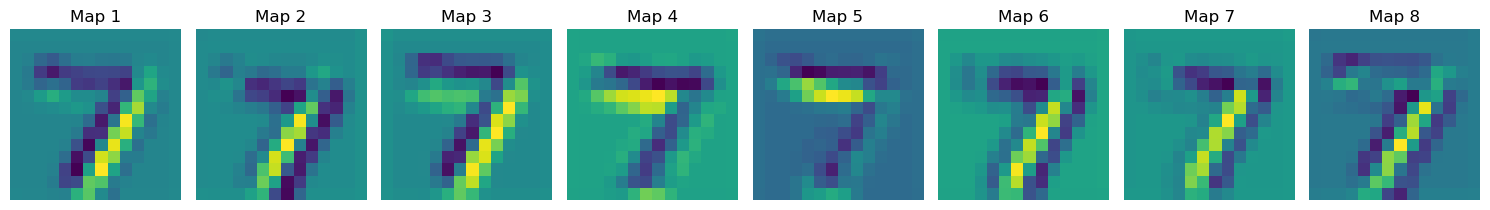

In [29]:
conv2_maps = activations["conv2"][0]
num_maps = min(8, conv2_maps.shape[0])

fig, axes = plt.subplots(1, num_maps, figsize=(15, 3))
for i in range(num_maps):
    axes[i].imshow(conv2_maps[i], cmap="viridis")
    axes[i].axis("off")
    axes[i].set_title(f"Map {i+1}")
plt.tight_layout()
plt.show()

In [30]:
hook1.remove()
hook2.remove()

Собираются и сравниваются итоговые метрики всех моделей (MLP с регуляризацией, без неё, с Sigmoid и CNN), что позволяет сделать вывод о качестве и эффективности различных подходов.

In [33]:
results = {
    "MLP ReLU + Reg": test_metrics_reg,
    "MLP ReLU no Reg": test_metrics_no_reg,
    "MLP Sigmoid + Reg": test_metrics_sigmoid,
    "CNN": test_metrics_cnn
}

for name, metrics in results.items():
    loss, acc, precision, recall, f1 = metrics
    print(f"{name}:")
    print(f"  Loss      = {loss:.4f}")
    print(f"  Accuracy  = {acc:.4f}")
    print(f"  Precision = {precision:.4f}")
    print(f"  Recall    = {recall:.4f}")
    print(f"  F1-score  = {f1:.4f}")
    print()

MLP ReLU + Reg:
  Loss      = 0.0653
  Accuracy  = 0.9793
  Precision = 0.9792
  Recall    = 0.9791
  F1-score  = 0.9791

MLP ReLU no Reg:
  Loss      = 0.0811
  Accuracy  = 0.9768
  Precision = 0.9767
  Recall    = 0.9767
  F1-score  = 0.9766

MLP Sigmoid + Reg:
  Loss      = 0.1096
  Accuracy  = 0.9675
  Precision = 0.9672
  Recall    = 0.9671
  F1-score  = 0.9671

CNN:
  Loss      = 0.0363
  Accuracy  = 0.9900
  Precision = 0.9901
  Recall    = 0.9900
  F1-score  = 0.9900

